<a href="https://colab.research.google.com/github/EleneJobava/facial-expression-recognition/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install kaggle wandb -q

In [8]:
import os
from google.colab import userdata
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Kaggle
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# WandB
os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')

import wandb
wandb.login()

True

In [9]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip
!ls

100% 285M/285M [00:18<00:00, 16.3MB/s]

challenges-in-representation-learning-facial-expression-recognition-challenge.zip
example_submission.csv
fer2013.tar.gz
icml_face_data.csv
sample_data
test.csv
train.csv


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import wandb
from google.colab import userdata
import os

In [11]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(train_df.head())
print("Shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())
print("Emotion counts:\n", train_df['emotion'].value_counts())

   emotion                                             pixels
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        0  151 150 147 155 148 133 111 140 170 174 182 15...
2        2  231 212 156 164 174 138 161 173 182 200 106 38...
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...
Shape: (28709, 2)
Columns: ['emotion', 'pixels']
Emotion counts:
 emotion
3    7215
6    4965
4    4830
2    4097
0    3995
5    3171
1     436
Name: count, dtype: int64


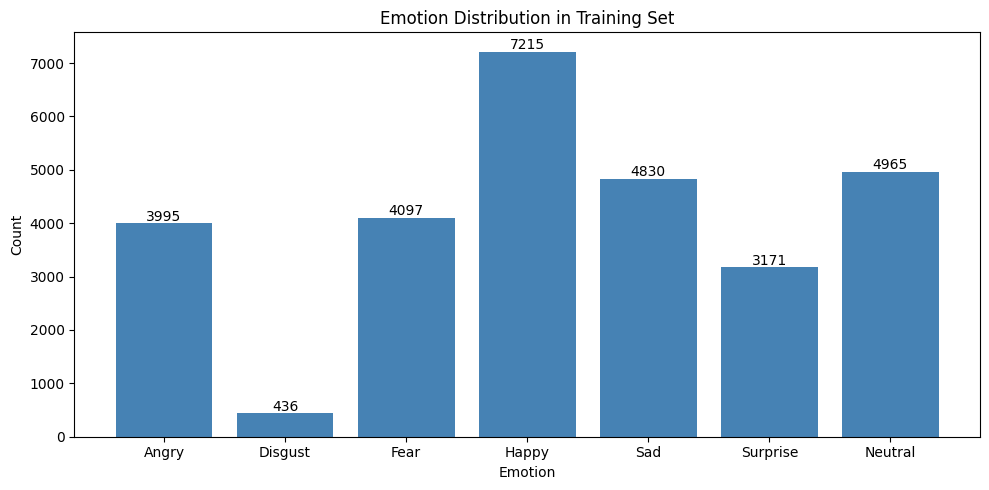

In [12]:
import matplotlib.pyplot as plt

emotion_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
counts = train_df['emotion'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(emotion_names, counts.values, color='steelblue')
plt.title('Emotion Distribution in Training Set')
plt.xlabel('Emotion')
plt.ylabel('Count')
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

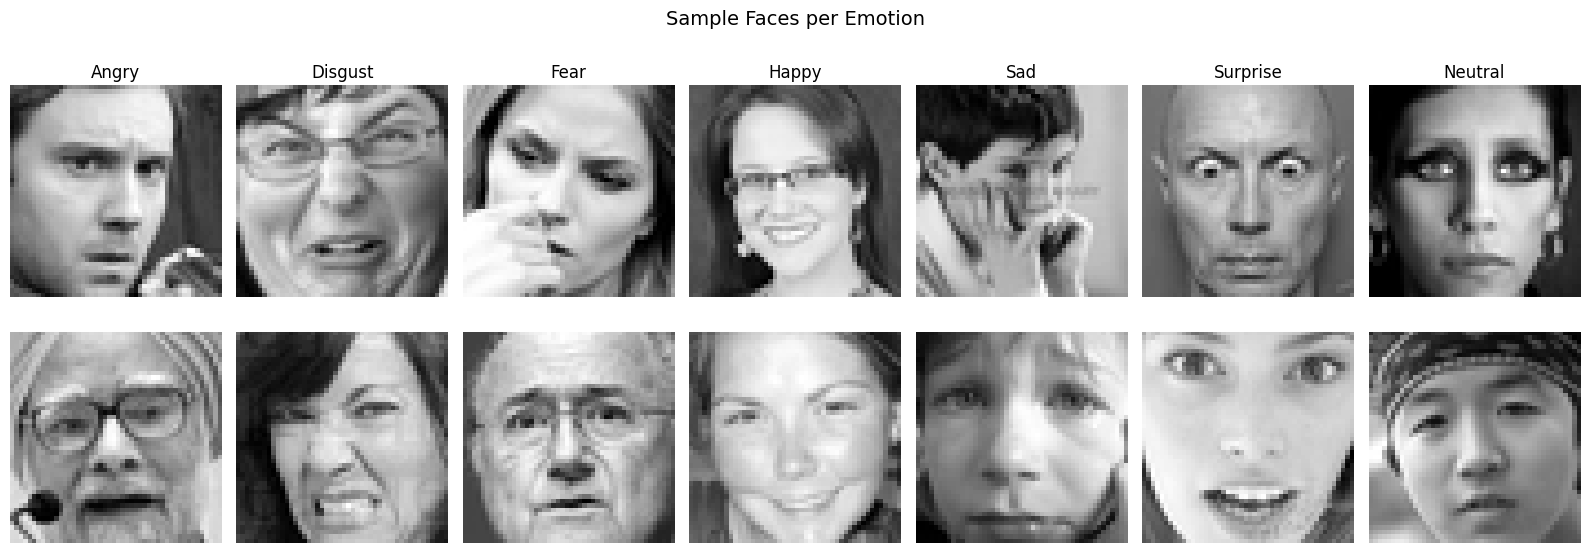

In [13]:
fig, axes = plt.subplots(2, 7, figsize=(16, 6))

for emotion_idx in range(7):
    samples = train_df[train_df['emotion'] == emotion_idx].head(2)
    for row, (_, sample) in enumerate(samples.iterrows()):
        pixels = np.array(sample['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        axes[row][emotion_idx].imshow(pixels, cmap='gray')
        axes[row][emotion_idx].axis('off')
        if row == 0:
            axes[row][emotion_idx].set_title(emotion_names[emotion_idx])

plt.suptitle('Sample Faces per Emotion', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
total = len(train_df)
print("Class imbalance analysis:")
print("-" * 35)
for i, name in enumerate(emotion_names):
    count = counts[i]
    pct = count/total*100
    bar = '█' * int(pct/2)
    print(f"{name:10s} {count:5d} ({pct:5.1f}%) {bar}")

Class imbalance analysis:
-----------------------------------
Angry       3995 ( 13.9%) ██████
Disgust      436 (  1.5%) 
Fear        4097 ( 14.3%) ███████
Happy       7215 ( 25.1%) ████████████
Sad         4830 ( 16.8%) ████████
Surprise    3171 ( 11.0%) █████
Neutral     4965 ( 17.3%) ████████


In [15]:
class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.emotions = df['emotion'].values
        self.images = np.array([
            np.array(row.split(), dtype=np.float32).reshape(48, 48)
            for row in df['pixels']
        ])
        # normalize to [0, 1]
        self.images = self.images / 255.0
        self.transform = transform

    def __len__(self):
        return len(self.emotions)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx]).unsqueeze(0)  # add channel dim → (1, 48, 48)
        label = torch.tensor(self.emotions[idx], dtype=torch.long)
        return image, label

In [16]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['emotion']  # keeps class balance in both splits
)
print(f"Train size: {len(train_df)} | Val size: {len(val_df)}")

Train size: 22967 | Val size: 5742


In [17]:
import torch

emotion_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

counts = train_df['emotion'].value_counts().sort_index().values
print("Samples per class:", counts)

class_weights = 1.0 / torch.tensor(counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()
print("Class weights:", class_weights)

Samples per class: [3196  349 3277 5772 3864 2537 3972]
Class weights: tensor([0.0686, 0.6282, 0.0669, 0.0380, 0.0567, 0.0864, 0.0552])


In [18]:
from PIL import Image
import torchvision.transforms as transforms

class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.emotions = df['emotion'].values
        self.images = np.array([
            np.array(row.split(), dtype=np.float32).reshape(48, 48)
            for row in df['pixels']
        ])
        self.images = self.images / 255.0
        self.transform = transform

    def __len__(self):
        return len(self.emotions)

    def __getitem__(self, idx):
        image = self.images[idx]  # (48, 48)
        label = torch.tensor(self.emotions[idx], dtype=torch.long)

        if self.transform:
            # convert to PIL so torchvision transforms work
            image = Image.fromarray((image * 255).astype(np.uint8))
            image = self.transform(image)
        else:
            image = torch.tensor(image).unsqueeze(0)  # (1, 48, 48)

        return image, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
])

print("Dataset class ready with augmentation support")

Dataset class ready with augmentation support


In [19]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

def get_loaders(batch_size=64, augment=True):
    train_dataset = FERDataset(train_df, transform=train_transform if augment else val_transform)
    val_dataset   = FERDataset(val_df,   transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

train_loader, val_loader = get_loaders()
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape} | Labels shape: {labels.shape}")
print(f"Pixel range: [{images.min():.2f}, {images.max():.2f}]")

Using device: cuda
Batch shape: torch.Size([64, 1, 48, 48]) | Labels shape: torch.Size([64])
Pixel range: [0.00, 1.00]


## Model 1 - Tiny CNN

In [20]:
import torch.nn as nn

class TinyCNN(nn.Module):
    """
    2 conv layers, no BatchNorm, no Dropout.
    Intentionally small, expected to underfit.
    """
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 24x24

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 12x12
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 12 * 12, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = TinyCNN()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2304, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=7, bias=True)
  )
)

Total parameters: 149,223


In [21]:
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import wandb
import time
import numpy as np

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    batch_losses = []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # gradient norm tells us if gradients are vanishing or exploding
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=999)

        optimizer.step()

        batch_losses.append(loss.item())
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return {
        'loss': total_loss / total,
        'accuracy': correct / total,
        'grad_norm': grad_norm.item(),
        'batch_loss_std': np.std(batch_losses),
        'preds': all_preds,
        'labels': all_labels,
    }


def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        'loss': total_loss / total,
        'accuracy': correct / total,
        'preds': all_preds,
        'labels': all_labels,
        'probs': np.array(all_probs),
    }


def get_per_class_accuracy(labels, preds, class_names):
    cm = confusion_matrix(labels, preds)
    per_class = cm.diagonal() / cm.sum(axis=1)
    return {f'val/acc_{class_names[i]}': per_class[i] for i in range(len(class_names))}


def log_gradient_flow(model):
    """Logs mean & max gradient per layer catches vanishing/exploding gradients."""
    grad_data = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_data[f'grads/mean_{name}'] = param.grad.abs().mean().item()
            grad_data[f'grads/max_{name}'] = param.grad.abs().max().item()
    return grad_data


def log_weight_stats(model):
    """Logs weight norms per layer detects dead neurons or exploding weights."""
    weight_data = {}
    for name, param in model.named_parameters():
        weight_data[f'weights/norm_{name}'] = param.data.norm().item()
        weight_data[f'weights/mean_{name}'] = param.data.mean().item()
    return weight_data


def plot_confusion_matrix(labels, preds, run_name):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotion_names,
                yticklabels=emotion_names, ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {run_name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    return fig


def plot_per_class_accuracy(labels, preds, run_name):
    cm = confusion_matrix(labels, preds)
    per_class = cm.diagonal() / cm.sum(axis=1)
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(emotion_names, per_class, color='steelblue')
    ax.set_ylim(0, 1)
    ax.set_title(f'Per-Class Accuracy — {run_name}')
    ax.set_ylabel('Accuracy')
    for bar, val in zip(bars, per_class):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=9)
    plt.tight_layout()
    return fig


def run_experiment(config):
    run = wandb.init(
        project="fer2013-emotion-recognition",
        name=config['run_name'],
        config=config,
        reinit=True
    )

    model = config['model'].to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    wandb.run.summary['total_parameters'] = total_params
    wandb.run.summary['trainable_parameters'] = trainable_params
    wandb.log({"model_architecture": wandb.Html(f"<pre>{str(model)}</pre>")})

    train_loader, val_loader = get_loaders(config['batch_size'], config['augment'])
    class_weights_device = class_weights.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_device)

    if config['optimizer_name'] == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    elif config['optimizer_name'] == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9, weight_decay=config['weight_decay'])

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])

    best_val_acc = 0
    best_val_loss = float('inf')
    epoch_times = []

    for epoch in range(config['epochs']):
        t0 = time.time()

        train_stats = train_epoch(model, train_loader, optimizer, criterion)
        val_stats   = val_epoch(model, val_loader, criterion)
        scheduler.step()

        epoch_time = time.time() - t0
        epoch_times.append(epoch_time)

        overfit_gap = train_stats['accuracy'] - val_stats['accuracy']
        loss_gap    = val_stats['loss'] - train_stats['loss']

        per_class_acc = get_per_class_accuracy(val_stats['labels'], val_stats['preds'], emotion_names)

        grad_logs   = log_gradient_flow(model) if (epoch + 1) % 5 == 0 else {}
        weight_logs = log_weight_stats(model)  if (epoch + 1) % 5 == 0 else {}

        log_dict = {
            # core metrics
            'epoch': epoch + 1,
            'train/loss': train_stats['loss'],
            'train/accuracy': train_stats['accuracy'],
            'val/loss': val_stats['loss'],
            'val/accuracy': val_stats['accuracy'],

            # overfitting analysis
            'analysis/overfit_gap': overfit_gap,
            'analysis/loss_gap': loss_gap,

            # training health
            'train/grad_norm': train_stats['grad_norm'],
            'train/batch_loss_std': train_stats['batch_loss_std'],

            # learning rate
            'train/lr': scheduler.get_last_lr()[0],

            # speed
            'epoch_time_seconds': epoch_time,
            'avg_epoch_time': np.mean(epoch_times),

            **per_class_acc,
            **grad_logs,
            **weight_logs,
        }
        wandb.log(log_dict)

        # track best
        if val_stats['accuracy'] > best_val_acc:
            best_val_acc = val_stats['accuracy']
            torch.save(model.state_dict(), f"{config['run_name']}_best.pth")
            wandb.run.summary['best_val_accuracy'] = best_val_acc
            wandb.run.summary['best_epoch'] = epoch + 1

        if val_stats['loss'] < best_val_loss:
            best_val_loss = val_stats['loss']
            wandb.run.summary['best_val_loss'] = best_val_loss

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{config['epochs']} | "
                  f"Train Loss: {train_stats['loss']:.4f} Acc: {train_stats['accuracy']:.3f} | "
                  f"Val Loss: {val_stats['loss']:.4f} Acc: {val_stats['accuracy']:.3f} | "
                  f"Gap: {overfit_gap:+.3f} | "
                  f"Grad Norm: {train_stats['grad_norm']:.3f} | "
                  f"Time: {epoch_time:.1f}s")

    wandb.run.summary['total_training_time'] = sum(epoch_times)
    wandb.run.summary['avg_epoch_time'] = np.mean(epoch_times)

    fig_cm = plot_confusion_matrix(val_stats['labels'], val_stats['preds'], config['run_name'])
    wandb.log({"charts/confusion_matrix": wandb.Image(fig_cm)})
    plt.close(fig_cm)

    fig_pc = plot_per_class_accuracy(val_stats['labels'], val_stats['preds'], config['run_name'])
    wandb.log({"charts/per_class_accuracy": wandb.Image(fig_pc)})
    plt.close(fig_pc)

    report = classification_report(val_stats['labels'], val_stats['preds'],
                                   target_names=emotion_names)
    print(f"\nClassification Report — {config['run_name']}:\n{report}")
    wandb.log({"classification_report": wandb.Html(f"<pre>{report}</pre>")})

    run.finish()
    return best_val_acc

print("Ready")

Ready


In [22]:
results = {}

tiny_cnn_config = {
    'run_name': 'tiny_cnn_baseline',
    'model': TinyCNN(),
    'lr': 1e-3,
    'batch_size': 64,
    'epochs': 30,
    'optimizer_name': 'adam',
    'augment': False,
    'weight_decay': 0,
}

best_acc = run_experiment(tiny_cnn_config)
results['tiny_cnn_baseline'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   5/30 | Train Loss: 1.4855 Acc: 0.429 | Val Loss: 1.5206 Acc: 0.434 | Gap: -0.005 | Grad Norm: 3.626 | Time: 5.9s
Epoch  10/30 | Train Loss: 1.2690 Acc: 0.497 | Val Loss: 1.4696 Acc: 0.462 | Gap: +0.035 | Grad Norm: 1.746 | Time: 6.1s
Epoch  15/30 | Train Loss: 1.1338 Acc: 0.542 | Val Loss: 1.4508 Acc: 0.468 | Gap: +0.074 | Grad Norm: 4.257 | Time: 6.2s
Epoch  20/30 | Train Loss: 1.0371 Acc: 0.578 | Val Loss: 1.5114 Acc: 0.471 | Gap: +0.108 | Grad Norm: 3.119 | Time: 6.1s
Epoch  25/30 | Train Loss: 0.9870 Acc: 0.594 | Val Loss: 1.5534 Acc: 0.482 | Gap: +0.111 | Grad Norm: 2.714 | Time: 6.2s
Epoch  30/30 | Train Loss: 0.9747 Acc: 0.602 | Val Loss: 1.5645 Acc: 0.483 | Gap: +0.119 | Grad Norm: 3.775 | Time: 5.9s

Classification Report — tiny_cnn_baseline:
              precision    recall  f1-score   support

       Angry       0.38      0.42      0.40       799
     Disgust       0.27      0.48      0.35        87
        Fear       0.34      0.29      0.31       820
       Happy 

analysis/loss_gap,▁▁▂▂▂▂▃▃▄▄▄▄▅▅▅▆▆▇▇▇▇▇▇███████
analysis/overfit_gap,▁▄▃▄▄▄▆▆▅▅▆▆▆▆▆▆▇▇▇█▇█████████
avg_epoch_time,██▃▁▂▁▂▁▁▂▁▂▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch_time_seconds,▆▆▁▂▆▁▆▂▃▆▁█▃▃▇▁▄▅▂▆▁▇▅▂▇▁▁▇▂▆
grads/max_classifier.1.bias,▇▃▃▆█▁
grads/max_classifier.1.weight,▅▁▄█▅▄
grads/max_classifier.3.bias,▄▇▂█▄▁
grads/max_classifier.3.weight,▁▄▃█▆▁
grads/max_features.0.bias,▅▁▆▄▁█
+41,...



Best Val Accuracy: 0.4854


## Medium CNN (Overfitting)

In [23]:
class MediumCNN(nn.Module):
    """
    4 conv layers + BatchNorm.
    Dropout is configurable setting to 0.0 will cause overfitting.
    """
    def __init__(self, num_classes=7, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 24x24
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 12x12
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 6x6
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 3x3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = MediumCNN(dropout=0.0)
total_params = sum(p.numel() for p in model.parameters())
print(f"MediumCNN total parameters: {total_params:,}")

MediumCNN total parameters: 537,927


In [24]:
def log_forward_backward_check(model, run_name):
    """
    Sanity checks recommended in lectures:
    - Forward: are outputs reasonable shape and scale?
    - Backward: do all parameters receive gradients?
    """
    print(f"\n── Forward/Backward Check: {run_name} ──")
    model = model.to(DEVICE)
    dummy_input = torch.randn(8, 1, 48, 48).to(DEVICE)
    dummy_labels = torch.randint(0, 7, (8,)).to(DEVICE)

    # Forward check
    model.train()
    outputs = model(dummy_input)
    print(f"Output shape:  {outputs.shape}")
    print(f"Output mean:   {outputs.mean().item():.4f}  (should be near 0 at init)")
    print(f"Output std:    {outputs.std().item():.4f}   (should be near 1 at init)")

    # Backward check
    criterion = nn.CrossEntropyLoss()
    loss = criterion(outputs, dummy_labels)
    loss.backward()
    print(f"✓ Loss value:    {loss.item():.4f}  (should be near {torch.log(torch.tensor(7.0)):.4f} = log(7))")

    no_grad = []
    for name, param in model.named_parameters():
        if param.grad is None:
            no_grad.append(name)

    if no_grad:
        print(f"No gradient:  {no_grad}")
    else:
        print(f"All {sum(1 for _ in model.parameters())} parameters received gradients")

    model.zero_grad()
    print("passed")

In [25]:
log_forward_backward_check(MediumCNN(dropout=0.0), 'medium_cnn_no_dropout')


── Forward/Backward Check: medium_cnn_no_dropout ──
Output shape:  torch.Size([8, 7])
Output mean:   0.0068  (should be near 0 at init)
Output std:    0.2971   (should be near 1 at init)
✓ Loss value:    2.0137  (should be near 1.9459 = log(7))
All 20 parameters received gradients
passed


In [26]:
medium_overfit_config = {
    'run_name': 'medium_cnn_no_dropout',
    'model': MediumCNN(dropout=0.0),
    'lr': 1e-3,
    'batch_size': 64,
    'epochs': 50,
    'optimizer_name': 'adam',
    'augment': False,
    'weight_decay': 0,
}

best_acc = run_experiment(medium_overfit_config)
results['medium_cnn_no_dropout'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

Epoch   5/50 | Train Loss: 0.9935 Acc: 0.603 | Val Loss: 1.4356 Acc: 0.524 | Gap: +0.079 | Grad Norm: 3.772 | Time: 5.4s
Epoch  10/50 | Train Loss: 0.4151 Acc: 0.835 | Val Loss: 1.6467 Acc: 0.570 | Gap: +0.265 | Grad Norm: 3.639 | Time: 5.4s
Epoch  15/50 | Train Loss: 0.0783 Acc: 0.982 | Val Loss: 2.3118 Acc: 0.573 | Gap: +0.408 | Grad Norm: 4.464 | Time: 5.4s
Epoch  20/50 | Train Loss: 0.0722 Acc: 0.976 | Val Loss: 2.8991 Acc: 0.577 | Gap: +0.399 | Grad Norm: 4.870 | Time: 6.5s
Epoch  25/50 | Train Loss: 0.0222 Acc: 0.997 | Val Loss: 2.8784 Acc: 0.582 | Gap: +0.414 | Grad Norm: 0.300 | Time: 6.8s
Epoch  30/50 | Train Loss: 0.0183 Acc: 0.997 | Val Loss: 2.9653 Acc: 0.584 | Gap: +0.413 | Grad Norm: 0.545 | Time: 6.2s
Epoch  35/50 | Train Loss: 0.0132 Acc: 0.997 | Val Loss: 2.9804 Acc: 0.581 | Gap: +0.416 | Grad Norm: 0.279 | Time: 5.4s
Epoch  40/50 | Train Loss: 0.0078 Acc: 0.997 | Val Loss: 3.0603 Acc: 0.587 | Gap: +0.410 | Grad Norm: 0.020 | Time: 5.6s
Epoch  45/50 | Train Loss: 0.004

analysis/loss_gap,▁▂▁▂▂▃▃▄▅▅▆▆▆▇▇▇▇▇▇█▇█████▇█████████████
analysis/overfit_gap,▁▃▂▃▃▄▅▆▆▇█████▇█████████████▇██████████
avg_epoch_time,▁█▅█▇██▇█▇█▇█▇███▇█▇████▇▇█▇████████████
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch_time_seconds,▁▆▁▇▁▆▁▇▁▇▅▄▁▇▂▁▂▂▆▇▇▁▄▅▁▁▇▁▅▄▇▂█▁▇▄▆▁██
grads/max_classifier.1.bias,▅▆██▁▂▁▁▁▂
grads/max_classifier.1.weight,▅▆█▇▂▂▁▁▁▂
grads/max_classifier.4.bias,█▄▃▃▁▁▁▁▁▁
grads/max_classifier.4.weight,█▅▅▃▁▂▁▁▁▂
grads/max_features.0.bias,█▅▅▅▂▁▁▁▁▁
+89,...



Best Val Accuracy: 0.5928


## Medium CNN (Properly Regularized)

In [27]:
log_forward_backward_check(MediumCNN(dropout=0.5), 'medium_cnn_regularized')


── Forward/Backward Check: medium_cnn_regularized ──
Output shape:  torch.Size([8, 7])
Output mean:   0.2516  (should be near 0 at init)
Output std:    0.3774   (should be near 1 at init)
✓ Loss value:    1.8040  (should be near 1.9459 = log(7))
All 20 parameters received gradients
passed


In [28]:
medium_regularized_config = {
    'run_name': 'medium_cnn_regularized',
    'model': MediumCNN(dropout=0.5),
    'lr': 1e-3,
    'batch_size': 64,
    'epochs': 50,
    'optimizer_name': 'adam',
    'augment': True,
    'weight_decay': 1e-4,
}

best_acc = run_experiment(medium_regularized_config)
results['medium_cnn_regularized'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

Epoch   5/50 | Train Loss: 1.5124 Acc: 0.416 | Val Loss: 1.4512 Acc: 0.486 | Gap: -0.070 | Grad Norm: 2.956 | Time: 12.1s
Epoch  10/50 | Train Loss: 1.3794 Acc: 0.461 | Val Loss: 1.3053 Acc: 0.493 | Gap: -0.032 | Grad Norm: 3.860 | Time: 12.9s
Epoch  15/50 | Train Loss: 1.2849 Acc: 0.491 | Val Loss: 1.2383 Acc: 0.526 | Gap: -0.035 | Grad Norm: 1.983 | Time: 11.9s
Epoch  20/50 | Train Loss: 1.1760 Acc: 0.528 | Val Loss: 1.1911 Acc: 0.548 | Gap: -0.020 | Grad Norm: 2.579 | Time: 12.9s
Epoch  25/50 | Train Loss: 1.0938 Acc: 0.561 | Val Loss: 1.1818 Acc: 0.572 | Gap: -0.011 | Grad Norm: 2.852 | Time: 12.3s
Epoch  30/50 | Train Loss: 0.9943 Acc: 0.591 | Val Loss: 1.2051 Acc: 0.587 | Gap: +0.004 | Grad Norm: 3.150 | Time: 12.8s
Epoch  35/50 | Train Loss: 0.9374 Acc: 0.616 | Val Loss: 1.1857 Acc: 0.609 | Gap: +0.006 | Grad Norm: 3.190 | Time: 11.9s
Epoch  40/50 | Train Loss: 0.8799 Acc: 0.637 | Val Loss: 1.1998 Acc: 0.611 | Gap: +0.026 | Grad Norm: 2.191 | Time: 13.0s
Epoch  45/50 | Train Los

analysis/loss_gap,▁▁▂▂▂▃▂▂▂▃▃▃▃▄▃▃▄▄▄▅▅▅▅▅▆▆▇▇▇▇▇▇████████
analysis/overfit_gap,▁▂▄▅▄▆▇▅▅▄▆▅▅▅▇▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████
avg_epoch_time,█▆▅▁▂▃▃▃▃▃▃▂▂▂▃▃▃▃▃▃▃▃▃▃▃▄▄▃▃▃▃▄▄▄▄▃▃▃▃▄
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
epoch_time_seconds,█▆▆▂▂▇▇▇▇▆▁▁▆▆▇▇▆▇▇▂▆▇▇▇▆█▇▆▁▃▇█▇▅▇▃▂▅▇█
grads/max_classifier.1.bias,▃▄▁█▆▃▃▄▁▄
grads/max_classifier.1.weight,▂█▃▆▇▃▅▄▁▂
grads/max_classifier.4.bias,▄▃▂▃██▁▂▅▃
grads/max_classifier.4.weight,█▃▁▂▃▂▄▃▁▁
grads/max_features.0.bias,▁█▃▇▇▇▃▇▄▅
+89,...



Best Val Accuracy: 0.6184


## Deep CNN with Residual Blocks

In [29]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class DeepResNet(nn.Module):
    """
    Custom residual architecture with skip connections.
    Dropout configurable for regularization experiments.
    """
    def __init__(self, num_classes=7, dropout=0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU()
        )
        self.layer1 = nn.Sequential(ResidualBlock(32), nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            ResidualBlock(64), nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            ResidualBlock(128), nn.MaxPool2d(2)
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            ResidualBlock(256), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.classifier(x)

model = DeepResNet()
total_params = sum(p.numel() for p in model.parameters())
print(f"DeepResNet total parameters: {total_params:,}")

DeepResNet total parameters: 1,960,199


In [30]:
log_forward_backward_check(DeepResNet(), 'deep_resnet_adam')


── Forward/Backward Check: deep_resnet_adam ──
Output shape:  torch.Size([8, 7])
Output mean:   -0.0050  (should be near 0 at init)
Output std:    1.4275   (should be near 1 at init)
✓ Loss value:    2.5178  (should be near 1.9459 = log(7))
All 50 parameters received gradients
passed


In [31]:
deep_resnet_config = {
    'run_name': 'deep_resnet_adam',
    'model': DeepResNet(),
    'lr': 1e-3,
    'batch_size': 64,
    'epochs': 60,
    'optimizer_name': 'adam',
    'augment': True,
    'weight_decay': 1e-4,
}

best_acc = run_experiment(deep_resnet_config)
results['deep_resnet_adam'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

Epoch   5/60 | Train Loss: 1.4889 Acc: 0.434 | Val Loss: 1.4243 Acc: 0.472 | Gap: -0.038 | Grad Norm: 2.830 | Time: 15.4s
Epoch  10/60 | Train Loss: 1.2190 Acc: 0.531 | Val Loss: 1.2397 Acc: 0.552 | Gap: -0.021 | Grad Norm: 8.117 | Time: 15.5s
Epoch  15/60 | Train Loss: 1.0799 Acc: 0.582 | Val Loss: 1.2083 Acc: 0.555 | Gap: +0.027 | Grad Norm: 2.668 | Time: 15.9s
Epoch  20/60 | Train Loss: 0.9398 Acc: 0.628 | Val Loss: 1.2352 Acc: 0.587 | Gap: +0.041 | Grad Norm: 2.072 | Time: 15.5s
Epoch  25/60 | Train Loss: 0.8516 Acc: 0.661 | Val Loss: 1.1519 Acc: 0.617 | Gap: +0.044 | Grad Norm: 1.962 | Time: 15.9s
Epoch  30/60 | Train Loss: 0.7246 Acc: 0.704 | Val Loss: 1.2051 Acc: 0.612 | Gap: +0.092 | Grad Norm: 2.405 | Time: 15.5s
Epoch  35/60 | Train Loss: 0.6347 Acc: 0.742 | Val Loss: 1.2596 Acc: 0.646 | Gap: +0.097 | Grad Norm: 2.276 | Time: 15.7s
Epoch  40/60 | Train Loss: 0.5131 Acc: 0.792 | Val Loss: 1.3355 Acc: 0.635 | Gap: +0.157 | Grad Norm: 2.782 | Time: 15.4s
Epoch  45/60 | Train Los

analysis/loss_gap,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▆▆▆▆▇▇▇███████
analysis/overfit_gap,▃▁▁▂▂▂▃▂▂▃▃▄▃▄▄▄▄▅▄▄▆▅▅▆▆▆▆▇▇▇▇▇▇███████
avg_epoch_time,█▃▂▁▃▅▅▄▄▅▆▆▆▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▆▇▇▇▇▇▇▇
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
epoch_time_seconds,▃▁▁▅▂▂▃▃▄▃▁▂▁▄▃▁▂▇█▁▂▂▂▁▁▅▂▁▂▃▂▅▄▂▃▂▃▂▅▂
grads/max_classifier.3.bias,▇█▄▄▃▂▅▃▂▁▂▁
grads/max_classifier.3.weight,▅█▅▄▃▂▃▂▁▁▂▁
grads/max_layer1.0.block.0.bias,▁▇▇▃▆▃▇█▇▅█▄
grads/max_layer1.0.block.0.weight,▁█▂▃▂▃▂▃▂▂▂▃
grads/max_layer1.0.block.1.bias,▁█▆▃▄█▇█▅▅▆▆
+209,...



Best Val Accuracy: 0.6557


## VGG-Style CNN

In [32]:
class VGGStyleCNN(nn.Module):
    """
    VGG-inspired architecture — very deep plain CNN, no skip connections.
    Purpose: contrast with DeepResNet to show importance of residual connections.
    """
    def __init__(self, num_classes=7, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = VGGStyleCNN()
total_params = sum(p.numel() for p in model.parameters())
print(f"VGGStyleCNN total parameters: {total_params:,}")

VGGStyleCNN total parameters: 3,225,319


In [33]:
log_forward_backward_check(VGGStyleCNN(), 'vgg_style_cnn')


── Forward/Backward Check: vgg_style_cnn ──
Output shape:  torch.Size([8, 7])
Output mean:   -0.1474  (should be near 0 at init)
Output std:    0.1964   (should be near 1 at init)
✓ Loss value:    1.9684  (should be near 1.9459 = log(7))
All 46 parameters received gradients
passed


In [34]:
vgg_config = {
    'run_name': 'vgg_style_cnn',
    'model': VGGStyleCNN(),
    'lr': 1e-3,
    'batch_size': 64,
    'epochs': 60,
    'optimizer_name': 'adam',
    'augment': True,
    'weight_decay': 1e-4,
}

best_acc = run_experiment(vgg_config)
results['vgg_style_cnn'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

Epoch   5/60 | Train Loss: 1.9353 Acc: 0.170 | Val Loss: 1.9334 Acc: 0.161 | Gap: +0.009 | Grad Norm: 0.386 | Time: 15.1s
Epoch  10/60 | Train Loss: 1.7530 Acc: 0.309 | Val Loss: 1.7088 Acc: 0.379 | Gap: -0.070 | Grad Norm: 0.922 | Time: 14.8s
Epoch  15/60 | Train Loss: 1.4933 Acc: 0.423 | Val Loss: 1.5033 Acc: 0.451 | Gap: -0.028 | Grad Norm: 1.452 | Time: 14.9s
Epoch  20/60 | Train Loss: 1.3286 Acc: 0.483 | Val Loss: 1.3038 Acc: 0.482 | Gap: +0.001 | Grad Norm: 3.338 | Time: 14.4s
Epoch  25/60 | Train Loss: 1.2314 Acc: 0.512 | Val Loss: 1.2569 Acc: 0.528 | Gap: -0.015 | Grad Norm: 2.787 | Time: 14.8s
Epoch  30/60 | Train Loss: 1.1546 Acc: 0.540 | Val Loss: 1.2795 Acc: 0.546 | Gap: -0.006 | Grad Norm: 1.725 | Time: 14.6s
Epoch  35/60 | Train Loss: 1.0822 Acc: 0.565 | Val Loss: 1.2779 Acc: 0.563 | Gap: +0.002 | Grad Norm: 2.013 | Time: 14.9s
Epoch  40/60 | Train Loss: 1.0178 Acc: 0.589 | Val Loss: 1.1740 Acc: 0.576 | Gap: +0.014 | Grad Norm: 3.244 | Time: 16.2s
Epoch  45/60 | Train Los

analysis/loss_gap,▂▂▂▂▂▃▃▃▁▃▂▁▁▁▁▂▄▃▂▃▃▄▄▆▅▅▅▇▆▆▇▇▇███████
analysis/overfit_gap,▅▅▅▅▇▁▅▇▃▃▃▄▅▄▄▄▄▅▅█▄▅▆▆▅▆▆▅▅▅▆▆▆▆▆▆▆▆▆▆
avg_epoch_time,█▅▅▆▇▇▆▆▅▅▄▃▃▂▁▁▁▁██▇▆▅▆▆▆███▇▇▇▇▇██▇▇▇▇
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
epoch_time_seconds,▁▁▂▂▁▁▂▁▁▁▁▁▁▁▁█▁▁▁▁▂▂▁▂▂▂▂▁▁▁▂▂▂▂▁▂▁▁▁▁
grads/max_classifier.1.bias,▁▄▃██▆▃▅▄▄▅▄
grads/max_classifier.1.weight,▁▂▂▅█▃▃▃▃▃▄▄
grads/max_classifier.4.bias,▄▄▁█▇▃▁▃▂▅▇▁
grads/max_classifier.4.weight,▃▃▂▅█▁▁▂▁▂▂▄
grads/max_classifier.7.bias,▂▇▆█▇▅▁▇▁▅▅▂
+193,...



Best Val Accuracy: 0.6109


## MobileNet-Style (Depthwise Separable Convolutions)

In [37]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, stride=stride, padding=1, groups=in_channels),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, out_channels, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class MobileNetStyle(nn.Module):
    def __init__(self, num_classes=7, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=1, padding=1), nn.BatchNorm2d(32), nn.ReLU(),

            DepthwiseSeparableConv(32, 64),   nn.MaxPool2d(2),
            DepthwiseSeparableConv(64, 128),  nn.MaxPool2d(2),
            DepthwiseSeparableConv(128, 128),
            DepthwiseSeparableConv(128, 256), nn.MaxPool2d(2),
            DepthwiseSeparableConv(256, 256),
            DepthwiseSeparableConv(256, 512), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))  # fixed — only one return


model = MobileNetStyle()
total_params = sum(p.numel() for p in model.parameters())
print(f"MobileNetStyle total parameters: {total_params:,}")

MobileNetStyle total parameters: 274,375


In [38]:
log_forward_backward_check(MobileNetStyle(), 'mobilenet_style')


── Forward/Backward Check: mobilenet_style ──
Output shape:  torch.Size([8, 7])
Output mean:   -0.2856  (should be near 0 at init)
Output std:    0.7889   (should be near 1 at init)
✓ Loss value:    2.0394  (should be near 1.9459 = log(7))
All 54 parameters received gradients
passed


In [39]:
mobilenet_config = {
    'run_name': 'mobilenet_style',
    'model': MobileNetStyle(),
    'lr': 1e-3,
    'batch_size': 64,
    'epochs': 60,
    'optimizer_name': 'adam',
    'augment': True,
    'weight_decay': 1e-4,
}

best_acc = run_experiment(mobilenet_config)
results['mobilenet_style'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

Epoch   5/60 | Train Loss: 1.3533 Acc: 0.489 | Val Loss: 1.2657 Acc: 0.511 | Gap: -0.022 | Grad Norm: 8.245 | Time: 14.5s
Epoch  10/60 | Train Loss: 1.1705 Acc: 0.544 | Val Loss: 1.1771 Acc: 0.575 | Gap: -0.032 | Grad Norm: 5.238 | Time: 14.4s
Epoch  15/60 | Train Loss: 1.0435 Acc: 0.581 | Val Loss: 1.1534 Acc: 0.589 | Gap: -0.008 | Grad Norm: 15.409 | Time: 14.4s
Epoch  20/60 | Train Loss: 0.9608 Acc: 0.612 | Val Loss: 1.2112 Acc: 0.588 | Gap: +0.025 | Grad Norm: 2.510 | Time: 14.6s
Epoch  25/60 | Train Loss: 0.8812 Acc: 0.639 | Val Loss: 1.1883 Acc: 0.616 | Gap: +0.023 | Grad Norm: 2.588 | Time: 14.6s
Epoch  30/60 | Train Loss: 0.8065 Acc: 0.668 | Val Loss: 1.2125 Acc: 0.618 | Gap: +0.050 | Grad Norm: 3.986 | Time: 14.0s
Epoch  35/60 | Train Loss: 0.7435 Acc: 0.689 | Val Loss: 1.2488 Acc: 0.616 | Gap: +0.073 | Grad Norm: 3.003 | Time: 14.4s
Epoch  40/60 | Train Loss: 0.6882 Acc: 0.717 | Val Loss: 1.3366 Acc: 0.627 | Gap: +0.089 | Grad Norm: 3.579 | Time: 14.4s
Epoch  45/60 | Train Lo

analysis/loss_gap,▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▄▅▅▅▆▆▆▆▆▇▆▇▇▇▇▇████████
analysis/overfit_gap,▁▄▃▄▄▄▄▅▄▅▄▅▅▅▅▅▆▅▆▆▆▆▆▇▇▇▇▇▇▇██████████
avg_epoch_time,█▇▅▆▅▃▄▄▄▄▄▄▄▄▄▃▂▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇███
epoch_time_seconds,█▇▅▇▆▄▇▅▇▆▆▇▆▆▃▆▁█▅▅▂▃▇▅▅▆▅▄▆▃▄▆▅▄▄▆▅█▇▅
grads/max_classifier.3.bias,▅▄█▂▂▃▂▂▁▂▁▁
grads/max_classifier.3.weight,█▅▇▁▂▂▁▂▁▁▁▂
grads/max_features.0.bias,▅▁█▁▁▂▂▁▇▄▂▂
grads/max_features.0.weight,▂▂█▁▁▂▁▂▁▂▂▁
grads/max_features.1.bias,▃▂█▁▁▃▁▂▂▂▂▁
+225,...



Best Val Accuracy: 0.6318


## ResNet18 (Transfer Learning)

In [40]:
import torchvision.models as models

def get_resnet18(num_classes=7, freeze_backbone=False):
    """
    Pretrained ResNet18 adapted for grayscale 48x48 input.
    freeze_backbone=True: only train the final FC layer (feature extraction).
    freeze_backbone=False: train entire network (full fine-tuning).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

model = get_resnet18()
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet18 total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 103MB/s]


ResNet18 total parameters: 11,173,831
Trainable parameters: 11,173,831


In [41]:
log_forward_backward_check(get_resnet18(), 'resnet18_finetune')


── Forward/Backward Check: resnet18_finetune ──
Output shape:  torch.Size([8, 7])
Output mean:   -0.2545  (should be near 0 at init)
Output std:    1.2497   (should be near 1 at init)
✓ Loss value:    2.7742  (should be near 1.9459 = log(7))
All 62 parameters received gradients
passed


In [42]:
resnet18_config = {
    'run_name': 'resnet18_finetune',
    'model': get_resnet18(),
    'lr': 5e-4,
    'batch_size': 64,
    'epochs': 40,
    'optimizer_name': 'adam',
    'augment': True,
    'weight_decay': 1e-4,
}

best_acc = run_experiment(resnet18_config)
results['resnet18_finetune'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

Epoch   5/40 | Train Loss: 1.4941 Acc: 0.434 | Val Loss: 1.4272 Acc: 0.495 | Gap: -0.061 | Grad Norm: 6.272 | Time: 17.0s
Epoch  10/40 | Train Loss: 1.1974 Acc: 0.537 | Val Loss: 1.2351 Acc: 0.560 | Gap: -0.023 | Grad Norm: 2.854 | Time: 15.9s
Epoch  15/40 | Train Loss: 0.9967 Acc: 0.607 | Val Loss: 1.2745 Acc: 0.566 | Gap: +0.040 | Grad Norm: 5.090 | Time: 15.6s
Epoch  20/40 | Train Loss: 0.7878 Acc: 0.686 | Val Loss: 1.2723 Acc: 0.599 | Gap: +0.087 | Grad Norm: 3.956 | Time: 15.8s
Epoch  25/40 | Train Loss: 0.5693 Acc: 0.774 | Val Loss: 1.4098 Acc: 0.603 | Gap: +0.171 | Grad Norm: 5.840 | Time: 15.6s
Epoch  30/40 | Train Loss: 0.3696 Acc: 0.856 | Val Loss: 1.6970 Acc: 0.604 | Gap: +0.252 | Grad Norm: 4.056 | Time: 15.9s
Epoch  35/40 | Train Loss: 0.2410 Acc: 0.906 | Val Loss: 1.9087 Acc: 0.606 | Gap: +0.300 | Grad Norm: 7.154 | Time: 15.7s
Epoch  40/40 | Train Loss: 0.1995 Acc: 0.923 | Val Loss: 1.9475 Acc: 0.606 | Gap: +0.317 | Grad Norm: 13.419 | Time: 15.4s

Classification Report 

analysis/loss_gap,▁▂▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▆▆▆▆▇▇▇▇██████
analysis/overfit_gap,▁▁▂▁▁▂▂▂▂▂▂▃▂▃▃▃▃▃▄▄▅▅▅▅▅▆▆▆▇▇▇▇█▇██████
avg_epoch_time,▅▃▂▁▆▆▆▅▇▇▇███▇▇▇▇▇▇▇▆▆▆▅▅▅▅▅▅▅▅▅▄▄▄▅▅▅▅
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch_time_seconds,▃▂▁▁█▄▂▃█▃▃▆▃▃▂▃▃▂▄▃▃▂▁▁▂▂▁▂▅▃▂▁▁▁▃▂▅▅▂▁
grads/max_bn1.bias,▁▁▂▂▂▂▃█
grads/max_bn1.weight,▂▂▂▂▄▁▃█
grads/max_conv1.weight,▃▁▂▁▂▁▂█
grads/max_fc.1.bias,▅▁█▄▄▂▄▂
grads/max_fc.1.weight,█▁▅▂▂▁▄▄
+257,...



Best Val Accuracy: 0.6094


## ResNet18 (Frozen Backbone)

In [44]:
def get_resnet18_v2(num_classes=7, freeze_backbone=False):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'fc' not in name and 'conv1' not in name:
                param.requires_grad = False

    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model

model = get_resnet18_v2(freeze_backbone=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

Trainable: 4,725,319 / 11,173,831


In [45]:
resnet18_frozen_v2_config = {
    'run_name': 'resnet18_frozen_v2',
    'model': get_resnet18_v2(freeze_backbone=True),
    'lr': 1e-3,
    'batch_size': 64,
    'epochs': 40,
    'optimizer_name': 'adam',
    'augment': True,
    'weight_decay': 1e-3,
}

best_acc = run_experiment(resnet18_frozen_v2_config)
results['resnet18_frozen_v2'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

Epoch   5/40 | Train Loss: 1.4995 Acc: 0.429 | Val Loss: 1.4382 Acc: 0.436 | Gap: -0.008 | Grad Norm: 2.910 | Time: 14.8s
Epoch  10/40 | Train Loss: 1.3540 Acc: 0.489 | Val Loss: 1.4874 Acc: 0.398 | Gap: +0.090 | Grad Norm: 4.547 | Time: 15.3s
Epoch  15/40 | Train Loss: 1.2117 Acc: 0.536 | Val Loss: 1.3818 Acc: 0.460 | Gap: +0.076 | Grad Norm: 6.269 | Time: 14.9s
Epoch  20/40 | Train Loss: 1.0704 Acc: 0.579 | Val Loss: 1.2885 Acc: 0.550 | Gap: +0.029 | Grad Norm: 5.487 | Time: 14.8s
Epoch  25/40 | Train Loss: 0.9157 Acc: 0.626 | Val Loss: 1.2231 Acc: 0.572 | Gap: +0.053 | Grad Norm: 4.045 | Time: 14.8s
Epoch  30/40 | Train Loss: 0.7376 Acc: 0.697 | Val Loss: 1.3026 Acc: 0.608 | Gap: +0.089 | Grad Norm: 3.976 | Time: 14.5s
Epoch  35/40 | Train Loss: 0.5587 Acc: 0.771 | Val Loss: 1.4220 Acc: 0.603 | Gap: +0.168 | Grad Norm: 4.764 | Time: 15.0s
Epoch  40/40 | Train Loss: 0.4722 Acc: 0.805 | Val Loss: 1.5081 Acc: 0.609 | Gap: +0.196 | Grad Norm: 6.208 | Time: 14.7s

Classification Report —

analysis/loss_gap,▁▃▁▂▁▁▂▂▂▂▃▂▂▃▃▃▂▂▃▃▂▃▃▃▄▄▄▅▄▅▅▆▆▆▇▇████
analysis/overfit_gap,▁▃▂▂▃▃▄▃▃▆▄▃▃▃▅▅▄▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇█████
avg_epoch_time,█▅▄▃▂▅▄▄▃▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
epoch_time_seconds,▅▂▃▂▂█▂▂▃▄▂▂▃▂▂▂▃▂▂▂▂▂▂▂▂▁▃▃▃▁▂▁▁▁▃▁▂▁▂▂
grads/max_conv1.weight,▂▁█▇▄▂▃▅
grads/max_fc.1.bias,▄█▇▅█▃▂▁
grads/max_fc.1.weight,▂▆█▄▃▂▁▂
grads/max_layer1.0.conv1.weight,▁▁▅█▂▂▄▆
grads/max_layer1.1.conv1.weight,▁▁▅▅▃▄▅█
+155,...



Best Val Accuracy: 0.6108


## ResNet18 Overfitting vs Underfitting Analysis

In [46]:
# OVERFIT: no augmentation, no regularization, high lr
resnet18_overfit_config = {
    'run_name': 'resnet18_overfit',
    'model': get_resnet18_v2(freeze_backbone=False),
    'lr': 1e-2,
    'batch_size': 64,
    'epochs': 30,
    'optimizer_name': 'adam',
    'augment': False,
    'weight_decay': 0,
}

best_acc = run_experiment(resnet18_overfit_config)
results['resnet18_overfit'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

Epoch   5/30 | Train Loss: 1.8816 Acc: 0.249 | Val Loss: 1.8372 Acc: 0.262 | Gap: -0.014 | Grad Norm: 0.632 | Time: 11.4s
Epoch  10/30 | Train Loss: 1.6627 Acc: 0.345 | Val Loss: 1.8732 Acc: 0.207 | Gap: +0.138 | Grad Norm: 0.424 | Time: 11.4s
Epoch  15/30 | Train Loss: 1.4067 Acc: 0.429 | Val Loss: 2.0641 Acc: 0.362 | Gap: +0.067 | Grad Norm: 0.489 | Time: 12.0s
Epoch  20/30 | Train Loss: 1.1533 Acc: 0.505 | Val Loss: 1.4644 Acc: 0.477 | Gap: +0.027 | Grad Norm: 0.682 | Time: 12.0s
Epoch  25/30 | Train Loss: 0.8919 Acc: 0.609 | Val Loss: 1.6980 Acc: 0.507 | Gap: +0.103 | Grad Norm: 0.604 | Time: 11.6s
Epoch  30/30 | Train Loss: 0.7222 Acc: 0.688 | Val Loss: 2.0020 Acc: 0.506 | Gap: +0.181 | Grad Norm: 0.685 | Time: 11.3s

Classification Report — resnet18_overfit:
              precision    recall  f1-score   support

       Angry       0.39      0.43      0.41       799
     Disgust       0.49      0.46      0.47        87
        Fear       0.36      0.31      0.33       820
       H

analysis/loss_gap,▆▁▃▂▂▂▂▄▂▃▂▃▂▃▅▃▃▃▄▄▄▅▅▅▆▆▇▇██
analysis/overfit_gap,▁▁▃▂▂▃▁▄▂▇▃▄▄▂▄▃▂▃▄▃▄▄▅▅▆▆▇▇██
avg_epoch_time,▆█▇▄▂▂▁▁▂▁▁▁▁▁▂▂▂▃▃▃▄▄▄▄▃▄▃▄▄▃
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch_time_seconds,▅▇▅▁▃▃▃▄▅▂▄▃▄▅█▅▃▅▇█▆▆▄▃▄▅▄▆▄▂
grads/max_bn1.bias,▁▁▂▆█▆
grads/max_bn1.weight,▁▃▅▃█▃
grads/max_conv1.weight,▁▃▃█▅▄
grads/max_fc.1.bias,█▄▅▁▂▂
grads/max_fc.1.weight,█▂▂▁▂▂
+257,...



Best Val Accuracy: 0.5084


In [47]:
# UNDERFIT: extremely high weight decay, very low lr
resnet18_underfit_config = {
    'run_name': 'resnet18_underfit',
    'model': get_resnet18_v2(freeze_backbone=False),
    'lr': 1e-5,
    'batch_size': 64,
    'epochs': 30,
    'optimizer_name': 'adam',
    'augment': True,
    'weight_decay': 1e-1,
}

best_acc = run_experiment(resnet18_underfit_config)
results['resnet18_underfit'] = best_acc
print(f"\nBest Val Accuracy: {best_acc:.4f}")

Epoch   5/30 | Train Loss: 1.9928 Acc: 0.221 | Val Loss: 1.8131 Acc: 0.262 | Gap: -0.042 | Grad Norm: 30.688 | Time: 16.6s
Epoch  10/30 | Train Loss: 1.7891 Acc: 0.282 | Val Loss: 1.6830 Acc: 0.321 | Gap: -0.039 | Grad Norm: 18.785 | Time: 16.4s
Epoch  15/30 | Train Loss: 1.6420 Acc: 0.334 | Val Loss: 1.6162 Acc: 0.367 | Gap: -0.033 | Grad Norm: 14.922 | Time: 15.9s
Epoch  20/30 | Train Loss: 1.5421 Acc: 0.372 | Val Loss: 1.5884 Acc: 0.384 | Gap: -0.012 | Grad Norm: 17.555 | Time: 15.9s
Epoch  25/30 | Train Loss: 1.5067 Acc: 0.386 | Val Loss: 1.5695 Acc: 0.402 | Gap: -0.015 | Grad Norm: 17.060 | Time: 15.8s
Epoch  30/30 | Train Loss: 1.4809 Acc: 0.393 | Val Loss: 1.5707 Acc: 0.401 | Gap: -0.008 | Grad Norm: 16.818 | Time: 15.5s

Classification Report — resnet18_underfit:
              precision    recall  f1-score   support

       Angry       0.32      0.30      0.31       799
     Disgust       0.11      0.51      0.18        87
        Fear       0.28      0.19      0.23       820
 

analysis/loss_gap,▁▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇█▇█▇█████
analysis/overfit_gap,▄▄▄▄▃▂▂▃▁▄▃▅▅▆▅▅▅▆█▇▇▇▇█▇█▇▇██
avg_epoch_time,▁▃▃▅▆██▇▇▇▇▇▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▅▅
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
epoch_time_seconds,▂▃▃▅▄█▃▄▃▄▄▂▃▃▃▂▅▄▂▂▃▃▃▃▂▇▁▁▁▂
grads/max_bn1.bias,█▂▂▁▂▁
grads/max_bn1.weight,█▄▂▂▂▁
grads/max_conv1.weight,█▃▅▂▁▁
grads/max_fc.1.bias,▁█▄▆▁▇
grads/max_fc.1.weight,█▂▁▁▁▁
+257,...



Best Val Accuracy: 0.4020


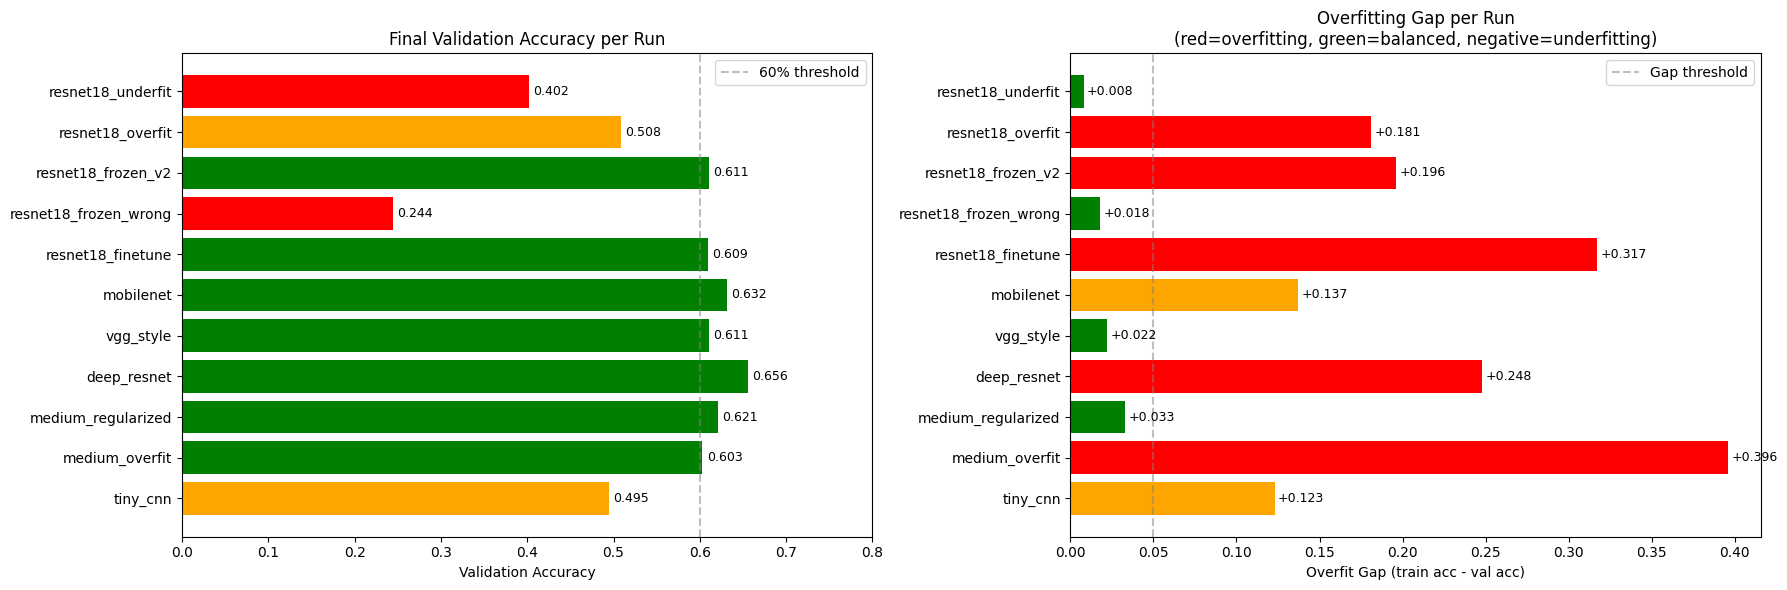

Plot saved!


In [6]:
import matplotlib.pyplot as plt
import numpy as np

all_results = {
    'tiny_cnn':              (0.4948, 0.123),
    'medium_overfit':        (0.6029, 0.396),
    'medium_regularized':    (0.6210, 0.033),
    'deep_resnet':           (0.6557, 0.248),
    'vgg_style':             (0.6109, 0.022),
    'mobilenet':             (0.6318, 0.137),
    'resnet18_finetune':     (0.6094, 0.317),
    'resnet18_frozen_wrong': (0.2442, 0.018),
    'resnet18_frozen_v2':    (0.6108, 0.196),
    'resnet18_overfit':      (0.5084, 0.181),
    'resnet18_underfit':     (0.4020, 0.008),
}

names = list(all_results.keys())
accs  = [v[0] for v in all_results.values()]
gaps  = [v[1] for v in all_results.values()]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Val Accuracy
colors = ['green' if a >= 0.60 else 'orange' if a >= 0.45 else 'red' for a in accs]
bars = axes[0].barh(names, accs, color=colors)
axes[0].axvline(x=0.60, color='gray', linestyle='--', alpha=0.5, label='60% threshold')
axes[0].set_xlabel('Validation Accuracy')
axes[0].set_title('Final Validation Accuracy per Run')
axes[0].set_xlim(0, 0.8)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{acc:.3f}', va='center', fontsize=9)
axes[0].legend()

#Plot 2: Overfit Gap
gap_colors = ['red' if g > 0.15 else 'orange' if g > 0.05 else 'green' for g in gaps]
bars2 = axes[1].barh(names, gaps, color=gap_colors)
axes[1].axvline(x=0.05, color='gray', linestyle='--', alpha=0.5, label='Gap threshold')
axes[1].set_xlabel('Overfit Gap (train acc - val acc)')
axes[1].set_title('Overfitting Gap per Run\n(red=overfitting, green=balanced, negative=underfitting)')
for bar, gap in zip(bars2, gaps):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{gap:+.3f}', va='center', fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.savefig('experiment_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [11]:
import subprocess
subprocess.run(['git', 'config', '--global', 'user.email', 'ejoba22@freeuni.edu.ge'])
subprocess.run(['git', 'config', '--global', 'user.name', 'EleneJobava'])

CompletedProcess(args=['git', 'config', '--global', 'user.name', 'EleneJobava'], returncode=0)

In [12]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
repo = 'EleneJobava/facial-expression-recognition'

%cd /content
!git clone https://{token}@github.com/{repo}.git
%cd facial-expression-recognition
!cp /content/experiment_results.png .
!git add .
!git commit -m "Add experiment results plot"
!git push origin main

/content
fatal: destination path 'facial-expression-recognition' already exists and is not an empty directory.
/content/facial-expression-recognition
[main 0ddc75b] Add experiment results plot
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 experiment_results.png
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 98.49 KiB | 10.94 MiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/EleneJobava/facial-expression-recognition.git
   1f35b4a..0ddc75b  main -> main


In [14]:
from google.colab import userdata
import os

token = userdata.get('GITHUB_TOKEN')
%cd /content/facial-expression-recognition
!git config --global user.email "ejoba22@freeuni.edu.ge"
!git config --global user.name "EleneJobava"
!cp /content/experiment_results.png . 2>/dev/null || echo "no png"
!git add .
!git commit -m "Update results" 2>/dev/null || echo "nothing to commit"
!git push origin main

/content/facial-expression-recognition
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
nothing to commit
Everything up-to-date
